# Phase 3 - Step 4: Lesion Segmentation (Lesion Ensemble)

In this notebook, we mathematically combine the best models into a **Weighted Soft-Voting Ensemble**.

**Why this works:**
- **Attention U-Net / U-Net++**: High recall/sensitivity. They find almost all lesions but sometimes guess wrongly.
- **YOLOv11**: Extremely high precision. When YOLO flags a microscopic point, it is almost certainly a real lesion.
By combining them, we maximize accuracy.


## 1. Setup & Imports


In [1]:
pip install segmentation-models-pytorch ultralytics

In [2]:
!pip install ultralytics segmentation-models-pytorch -q
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import segmentation_models_pytorch as smp
from ultralytics import YOLO




In [3]:
"""
Retinal DR Detection — Lesion Segmentation Dataset
=====================================================
Multi-label dataset for simultaneous segmentation of 5 lesion types.

Key difference from VesselDataset (src/dataset.py):
  - Vessel segmentation = SINGLE binary mask  → model outputs (B, 1, H, W)
  - Lesion segmentation = FIVE  binary masks  → model outputs (B, 5, H, W)

Each image produces a stacked mask tensor of shape (5, H, W) where:
  Channel 0 → MA  (Microaneurysms)        — earliest sign of DR
  Channel 1 → HE  (Hemorrhages)           — blood leaking from vessels
  Channel 2 → EX  (Hard Exudates)         — lipid deposits, sign of macular edema
  Channel 3 → OD  (Optic Disc)            — anatomical landmark for spatial reference
  Channel 4 → CW  (Cotton Wool spots)     — nerve fiber infarcts, severe ischemia

Albumentations automatically applies the SAME spatial transform (flip,
rotate, distort) to ALL mask channels, ensuring geometric consistency.
"""

import os
import cv2
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2


# ============================================================
# The 5 lesion types — this is the SINGLE source of truth
# ============================================================
LESION_TYPES = ['MA', 'HE', 'EX', 'OD', 'CW']
NUM_LESION_CLASSES = len(LESION_TYPES)


class LesionDataset(Dataset):
    """
    Multi-label retinal lesion segmentation dataset.

    For each fundus image it loads 5 binary masks (one per lesion type)
    and stacks them into a single (5, H, W) tensor.  If a mask file
    doesn't exist for a particular lesion type, a zero-mask (= "no
    lesion present") is used — this is the correct ground truth.

    Args:
        csv_file     : Path to CSV with 'img_id' and 'img_path' columns.
        base_dir     : Root directory of the processed dataset
                       (e.g. 'dataset_stage1_segmentation_processed').
        transform    : Albumentations Compose pipeline (from get_*_transforms).
        lesion_mask_dir : Sub-folder containing per-type mask folders
                         (default 'lesion_masks').
        lesion_types : Which lesion types to load (default LESION_TYPES).
    """

    def __init__(self, csv_file, base_dir, transform=None,
                 lesion_mask_dir='lesion_masks',
                 lesion_types=None):
        self.df = pd.read_csv(csv_file)

        # Keep only rows that have at least one lesion mask
        if 'has_lesion' in self.df.columns:
            self.df = self.df[self.df['has_lesion'] == True].reset_index(drop=True)

        self.base_dir = base_dir
        self.lesion_mask_dir = lesion_mask_dir
        self.transform = transform
        self.lesion_types = lesion_types or LESION_TYPES

    def __len__(self):
        return len(self.df)

    # ----------------------------------------------------------
    def _load_single_mask(self, img_id, lesion_type):
        """
        Attempt to load one lesion mask from disk.

        Path convention (set during preprocessing):
            {base_dir}/lesion_masks/{lesion_type}/{img_id}
            e.g.  dataset_processed/lesion_masks/MA/IDRID_train_IDRiD_01.png

        Returns:
            np.ndarray (H, W) float32 with values 0.0 / 1.0, or None.
        """
        mask_path = os.path.join(
            self.base_dir, self.lesion_mask_dir, lesion_type, img_id
        )
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                return (mask > 127).astype(np.float32)
        return None

    # ----------------------------------------------------------
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['img_id']               # e.g. "IDRID_train_IDRiD_01.png"

        # ---- 1. Load RGB image ----
        img_path = os.path.join(self.base_dir, row['img_path'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        # ---- 2. Load & stack all 5 lesion masks → (H, W, 5) ----
        #   Albumentations treats a 3-D mask array as a multi-channel
        #   mask and applies the same geometric transform to every channel.
        mask_stack = np.zeros((h, w, len(self.lesion_types)), dtype=np.float32)
        for i, lt in enumerate(self.lesion_types):
            m = self._load_single_mask(img_id, lt)
            if m is not None:
                mask_stack[:, :, i] = m

        # ---- 3. Apply augmentations ----
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask_stack)
            image = augmented['image']       # Tensor (3, H, W) after ToTensorV2
            mask_stack = augmented['mask']    # Tensor (5, H, W) after ToTensorV2

        # ---- 4. Ensure correct tensor format: (C, H, W) ----
        #   ToTensorV2 in newer albumentations does NOT auto-transpose
        #   multi-channel masks, so we handle it explicitly.
        if isinstance(mask_stack, np.ndarray):
            # No transform applied — convert manually
            mask_tensor = torch.from_numpy(
                mask_stack.transpose(2, 0, 1)  # (H, W, 5) → (5, H, W)
            ).float()
        elif isinstance(mask_stack, torch.Tensor):
            if mask_stack.dim() == 3 and mask_stack.shape[-1] == len(self.lesion_types):
                # Shape is (H, W, 5) — need to permute to (5, H, W)
                mask_tensor = mask_stack.permute(2, 0, 1).float()
            else:
                mask_tensor = mask_stack.float()
        else:
            mask_tensor = torch.as_tensor(mask_stack).float()

        return image, mask_tensor


# ============================================================
# Augmentation Pipelines (same as vessel, reused here)
# ============================================================

def get_train_transforms(img_size=512):
    """
    Training augmentation pipeline.

    Geometric transforms handle fundus image variability:
      - Different camera angles       → flips & rotations
      - Different fields of view      → scale variations
      - Patient movement              → shift & distortion

    Color transforms handle:
      - Different fundus camera brands → brightness/contrast variation
      - Different illumination         → hue/saturation shifts
    """
    return A.Compose([
        A.Resize(img_size, img_size),

        # === Geometric Augmentations ===
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Affine(
            translate_percent={'x': (-0.0625, 0.0625), 'y': (-0.0625, 0.0625)},
            scale=(0.9, 1.1),
            rotate=(-45, 45),
            border_mode=cv2.BORDER_CONSTANT,
            p=0.5
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.2),

        # === Color / Illumination Augmentations ===
        A.ColorJitter(brightness=0.2, contrast=0.2,
                      saturation=0.2, hue=0.1, p=0.4),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.GaussNoise(std_range=(0.02, 0.05), p=0.2),

        # === Normalization (ImageNet stats for pretrained backbones) ===
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


def get_val_transforms(img_size=512):
    """
    Validation/Test transform — NO augmentation, only resize + normalize.
    We must evaluate on clean, unaugmented images for fair comparison.
    """
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


In [4]:
"""
Retinal DR Detection — Lesion Evaluation Metrics
==================================================
Per-channel and overall metrics for multi-label lesion segmentation.

For each of the 5 lesion types we compute:
  - Dice Coefficient  (primary metric)
  - IoU / Jaccard Index
  - Sensitivity (Recall)  — "did we find all lesion pixels?"
  - Specificity            — "did we avoid false alarms?"
  - Precision (PPV)

Then we report both per-type scores AND macro-averaged scores.
"""

import numpy as np
import torch
from sklearn.metrics import roc_auc_score, average_precision_score




def evaluate_multilabel_batch(pred_logits, targets, threshold=0.5):
    """
    Compute metrics for a batch of multi-label predictions.

    Args:
        pred_logits : (B, C, H, W)  raw model output BEFORE sigmoid
        targets     : (B, C, H, W)  binary ground truth
        threshold   : Binarization threshold for sigmoid output

    Returns:
        dict with per-channel and mean metrics
        Example: {'dice_MA': 0.72, ..., 'dice_mean': 0.68, ...}
    """
    smooth = 1e-6
    with torch.no_grad():
        pred_probs  = torch.sigmoid(pred_logits)
        pred_binary = (pred_probs > threshold).float()

        B, C, H, W = pred_binary.shape
        metrics = {}

        for ch in range(C):
            p = pred_binary[:, ch, :, :].contiguous().view(-1)
            t = targets[:, ch, :, :].contiguous().view(-1)

            tp = (p * t).sum()
            fp = (p * (1 - t)).sum()
            fn = ((1 - p) * t).sum()
            tn = ((1 - p) * (1 - t)).sum()

            dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
            iou  = (tp + smooth) / (tp + fp + fn + smooth)
            sens = (tp + smooth) / (tp + fn + smooth)
            spec = (tn + smooth) / (tn + fp + smooth)
            prec = (tp + smooth) / (tp + fp + smooth)

            lt = LESION_TYPES[ch] if ch < len(LESION_TYPES) else f'ch{ch}'
            metrics[f'dice_{lt}'] = dice.item()
            metrics[f'iou_{lt}']  = iou.item()
            metrics[f'sens_{lt}'] = sens.item()
            metrics[f'spec_{lt}'] = spec.item()
            metrics[f'prec_{lt}'] = prec.item()

        # Macro averages
        for m in ['dice', 'iou', 'sens', 'spec', 'prec']:
            vals = [metrics[f'{m}_{LESION_TYPES[c]}'] for c in range(C)]
            metrics[f'{m}_mean'] = np.mean(vals)

    return metrics


def evaluate_multilabel_full(pred_probs_all, targets_all,
                             num_classes=None, threshold=0.5):
    """
    Compute ALL metrics on the full test set (after collecting
    all predictions across batches).

    Args:
        pred_probs_all : np.array (N, C, H, W)  sigmoid probabilities
        targets_all    : np.array (N, C, H, W)  binary ground truth
        num_classes    : Number of channels (default: len(LESION_TYPES))

    Returns:
        dict with per-channel AND macro-averaged metrics including AUC
    """
    smooth = 1e-6
    if num_classes is None:
        num_classes = len(LESION_TYPES)

    pred_binary = (pred_probs_all > threshold).astype(np.float32)
    results = {}

    for ch in range(num_classes):
        p_flat = pred_binary[:, ch, :, :].ravel()
        t_flat = targets_all[:, ch, :, :].ravel()
        prob_flat = pred_probs_all[:, ch, :, :].ravel()

        tp = (p_flat * t_flat).sum()
        fp = (p_flat * (1 - t_flat)).sum()
        fn = ((1 - p_flat) * t_flat).sum()
        tn = ((1 - p_flat) * (1 - t_flat)).sum()

        dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
        iou  = (tp + smooth) / (tp + fp + fn + smooth)
        sens = (tp + smooth) / (tp + fn + smooth)
        spec = (tn + smooth) / (tn + fp + smooth)
        prec = (tp + smooth) / (tp + fp + smooth)
        acc  = (tp + tn) / (tp + tn + fp + fn + smooth)

        # AUC metrics (may fail if all labels are the same)
        try:
            auc_roc = roc_auc_score(t_flat, prob_flat)
        except ValueError:
            auc_roc = 0.0
        try:
            auc_pr = average_precision_score(t_flat, prob_flat)
        except ValueError:
            auc_pr = 0.0

        lt = LESION_TYPES[ch] if ch < len(LESION_TYPES) else f'ch{ch}'
        results[f'dice_{lt}']    = float(dice)
        results[f'iou_{lt}']     = float(iou)
        results[f'sens_{lt}']    = float(sens)
        results[f'spec_{lt}']    = float(spec)
        results[f'prec_{lt}']    = float(prec)
        results[f'acc_{lt}']     = float(acc)
        results[f'auc_roc_{lt}'] = float(auc_roc)
        results[f'auc_pr_{lt}']  = float(auc_pr)

    # Macro averages
    for m in ['dice', 'iou', 'sens', 'spec', 'prec', 'acc',
              'auc_roc', 'auc_pr']:
        vals = [results[f'{m}_{LESION_TYPES[c]}'] for c in range(num_classes)]
        results[f'{m}_mean'] = float(np.mean(vals))

    return results


## 2. Configuration & Paths

Make sure these paths correctly point to where your best `.pth` and `.pt` weights are saved!


In [5]:
import zipfile


zip_path = "DR_dataset_processed.zip"     # Change this to your actual zip file name
extract_dir = "dataset"           # Where to extract your files

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [9]:
# GPU Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Data paths
DATA_DIR = 'dataset' # Change if needed
TEST_CSV = os.path.join(DATA_DIR, 'test_split.csv')

# Model Weights Paths (Update these based on your exact Colab folder structure!)
ATTN_UNET_WEIGHTS = 'Attention_UNet_ResNet34_best.pth'
UNETPP_WEIGHTS = 'UNetPP_ResNet34_best.pth'
YOLO_WEIGHTS = 'YOLOV11_best.pt'

CFG = {
    'threshold': 0.5,
    'out_channels': 5
}


Using device: cuda


## 3. Load All 3 Models into Memory


In [11]:
# ----------------------------------------------------
# 1. Load Attention U-Net
# ----------------------------------------------------
attn_unet = smp.Unet(
    encoder_name='resnet34',
    encoder_weights=None,
    in_channels=3,
    classes=CFG['out_channels'],
).to(device)
attn_unet.load_state_dict(torch.load(ATTN_UNET_WEIGHTS, map_location=device, weights_only=False)['model_state_dict'])
attn_unet.eval()

# ----------------------------------------------------
# 2. Load U-Net++
# ----------------------------------------------------
# Note: Based on your previous notebooks, the UNet++ architecture was saved using the standard Unet class
unet_pp = smp.Unet(
    encoder_name='resnet34',
    encoder_weights=None,
    in_channels=3,
    classes=CFG['out_channels'],
).to(device)
unet_pp.load_state_dict(torch.load(UNETPP_WEIGHTS, map_location=device, weights_only=False)['model_state_dict'])
unet_pp.eval()

# ----------------------------------------------------
# 3. Load YOLOv11
# ----------------------------------------------------
yolo_model = YOLO(YOLO_WEIGHTS)

print("✅ All 3 Models Loaded Successfully!")


✅ All 3 Models Loaded Successfully!


## 4. Run Inference & Generate Probabilities

This will take a few minutes. We run all 3 models on the entire test set simultaneously.


In [12]:
# Load Dataset
test_dataset = LesionDataset(TEST_CSV, DATA_DIR, transform=get_val_transforms(512), lesion_types=LESION_TYPES)
df_test = pd.read_csv(TEST_CSV)
df_test = df_test[df_test['has_lesion'] == True].reset_index(drop=True)

# Arrays to hold predictions
preds_attn = []
preds_unpp = []
preds_yolo = []
all_targets = []

with torch.no_grad():
    for idx, row in tqdm(df_test.iterrows(), total=len(df_test), desc='Generating Multi-Model Predictions'):
        # 1. Get PyTorch Inputs
        image_tensor, gt_mask = test_dataset[idx]
        image_batch = image_tensor.unsqueeze(0).to(device)

        # 2. Run Attention U-Net
        out_attn = attn_unet(image_batch)
        prob_attn = torch.sigmoid(out_attn).cpu().numpy()[0] # Shape: (5, 512, 512)
        preds_attn.append(prob_attn)

        # 3. Run U-Net++
        out_unpp = unet_pp(image_batch)
        prob_unpp = torch.sigmoid(out_unpp).cpu().numpy()[0] # Shape: (5, 512, 512)
        preds_unpp.append(prob_unpp)

        # 4. Run YOLOv11 (Reverse Conversion)
        img_path = os.path.join(DATA_DIR, row['img_path'])
        res = yolo_model.predict(img_path, imgsz=512, verbose=False, retina_masks=True)[0]

        prob_yolo = np.zeros((5, 512, 512), dtype=np.float32)
        if res.masks is not None:
            masks_data = res.masks.data.cpu().numpy()
            classes = res.boxes.cls.cpu().numpy().astype(int)
            for inst_idx, cls_id in enumerate(classes):
                if cls_id < 5:
                    prob_yolo[cls_id] = np.maximum(prob_yolo[cls_id], masks_data[inst_idx])
        preds_yolo.append(prob_yolo)

        # Save Ground Truth
        all_targets.append(gt_mask.numpy())

# Convert lists to NumPy arrays (N, 5, 512, 512)
preds_attn = np.stack(preds_attn, axis=0)
preds_unpp = np.stack(preds_unpp, axis=0)
preds_yolo = np.stack(preds_yolo, axis=0)
all_targets = np.stack(all_targets, axis=0)

print("✅ Inference Complete! Extracted probabilities for all models.")


Generating Multi-Model Predictions: 100%|██████████| 37/37 [00:05<00:00,  6.84it/s]


✅ Inference Complete! Extracted probabilities for all models.


## 5. Evaluate the Ensembles

We will evaluate **two** different ensemble strategies:
1. **2-Model Ensemble**: Attention U-Net (50%) + YOLOv11 (50%)
2. **3-Model Ensemble**: Attention U-Net (40%) + U-Net++ (40%) + YOLOv11 (20%)


In [13]:
def print_results(results_dict, title):
    print(f'\n{"="*60}')
    print(f'  {title}')
    print(f'{"="*60}')
    for lt in LESION_TYPES:
        print(f'\n  {lt}:')
        print(f'    Dice: {results_dict[f"dice_{lt}"]:.4f}  |  IoU: {results_dict[f"iou_{lt}"]:.4f}')
        print(f'    Sens: {results_dict[f"sens_{lt}"]:.4f}  |  Spec: {results_dict[f"spec_{lt}"]:.4f}')
        print(f'    Prec: {results_dict[f"prec_{lt}"]:.4f}  |  AUC: {results_dict[f"auc_roc_{lt}"]:.4f}')

    print(f'\n  MACRO AVERAGE:')
    print(f'    Dice: {results_dict["dice_mean"]:.4f}  |  IoU: {results_dict["iou_mean"]:.4f}')
    print(f'    Sens: {results_dict["sens_mean"]:.4f}  |  Spec: {results_dict["spec_mean"]:.4f}')
    print(f'    Prec: {results_dict["prec_mean"]:.4f}')
    print(f'{"="*60}')

# ----------------------------------------------------
# Ensemble 1: Attention U-Net (50%) + YOLO (50%)
# ----------------------------------------------------
ensemble_2_prob = (0.5 * preds_attn) + (0.5 * preds_yolo)
results_ens2 = evaluate_multilabel_full(ensemble_2_prob, all_targets)
print_results(results_ens2, "TEST RESULTS — 2-Model Ensemble (50% Attn UNet + 50% YOLO)")

# ----------------------------------------------------
# Ensemble 2: Attention U-Net (40%) + U-Net++ (40%) + YOLO (20%)
# ----------------------------------------------------
ensemble_3_prob = (0.4 * preds_attn) + (0.4 * preds_unpp) + (0.2 * preds_yolo)
results_ens3 = evaluate_multilabel_full(ensemble_3_prob, all_targets)
print_results(results_ens3, "TEST RESULTS — 3-Model Ensemble (40% Attn | 40% UNet++ | 20% YOLO)")



  TEST RESULTS — 2-Model Ensemble (50% Attn UNet + 50% YOLO)

  MA:
    Dice: 0.3027  |  IoU: 0.1783
    Sens: 0.1985  |  Spec: 0.9998
    Prec: 0.6367  |  AUC: 0.8205

  HE:
    Dice: 0.4644  |  IoU: 0.3024
    Sens: 0.3998  |  Spec: 0.9997
    Prec: 0.5539  |  AUC: 0.8911

  EX:
    Dice: 0.4449  |  IoU: 0.2861
    Sens: 0.3619  |  Spec: 0.9996
    Prec: 0.5773  |  AUC: 0.9522

  OD:
    Dice: 0.9483  |  IoU: 0.9017
    Sens: 0.9433  |  Spec: 0.9992
    Prec: 0.9534  |  AUC: 0.9988

  CW:
    Dice: 0.2346  |  IoU: 0.1329
    Sens: 0.1417  |  Spec: 0.9999
    Prec: 0.6815  |  AUC: 0.8082

  MACRO AVERAGE:
    Dice: 0.4790  |  IoU: 0.3603
    Sens: 0.4090  |  Spec: 0.9997
    Prec: 0.6806

  TEST RESULTS — 3-Model Ensemble (40% Attn | 40% UNet++ | 20% YOLO)

  MA:
    Dice: 0.4434  |  IoU: 0.2848
    Sens: 0.3466  |  Spec: 0.9996
    Prec: 0.6149  |  AUC: 0.8958

  HE:
    Dice: 0.5314  |  IoU: 0.3619
    Sens: 0.4317  |  Spec: 0.9998
    Prec: 0.6910  |  AUC: 0.9199

  EX:
    Dice: 

## 6. Visualization & Comparison

Let's visually compare the actual predictions on a test image!


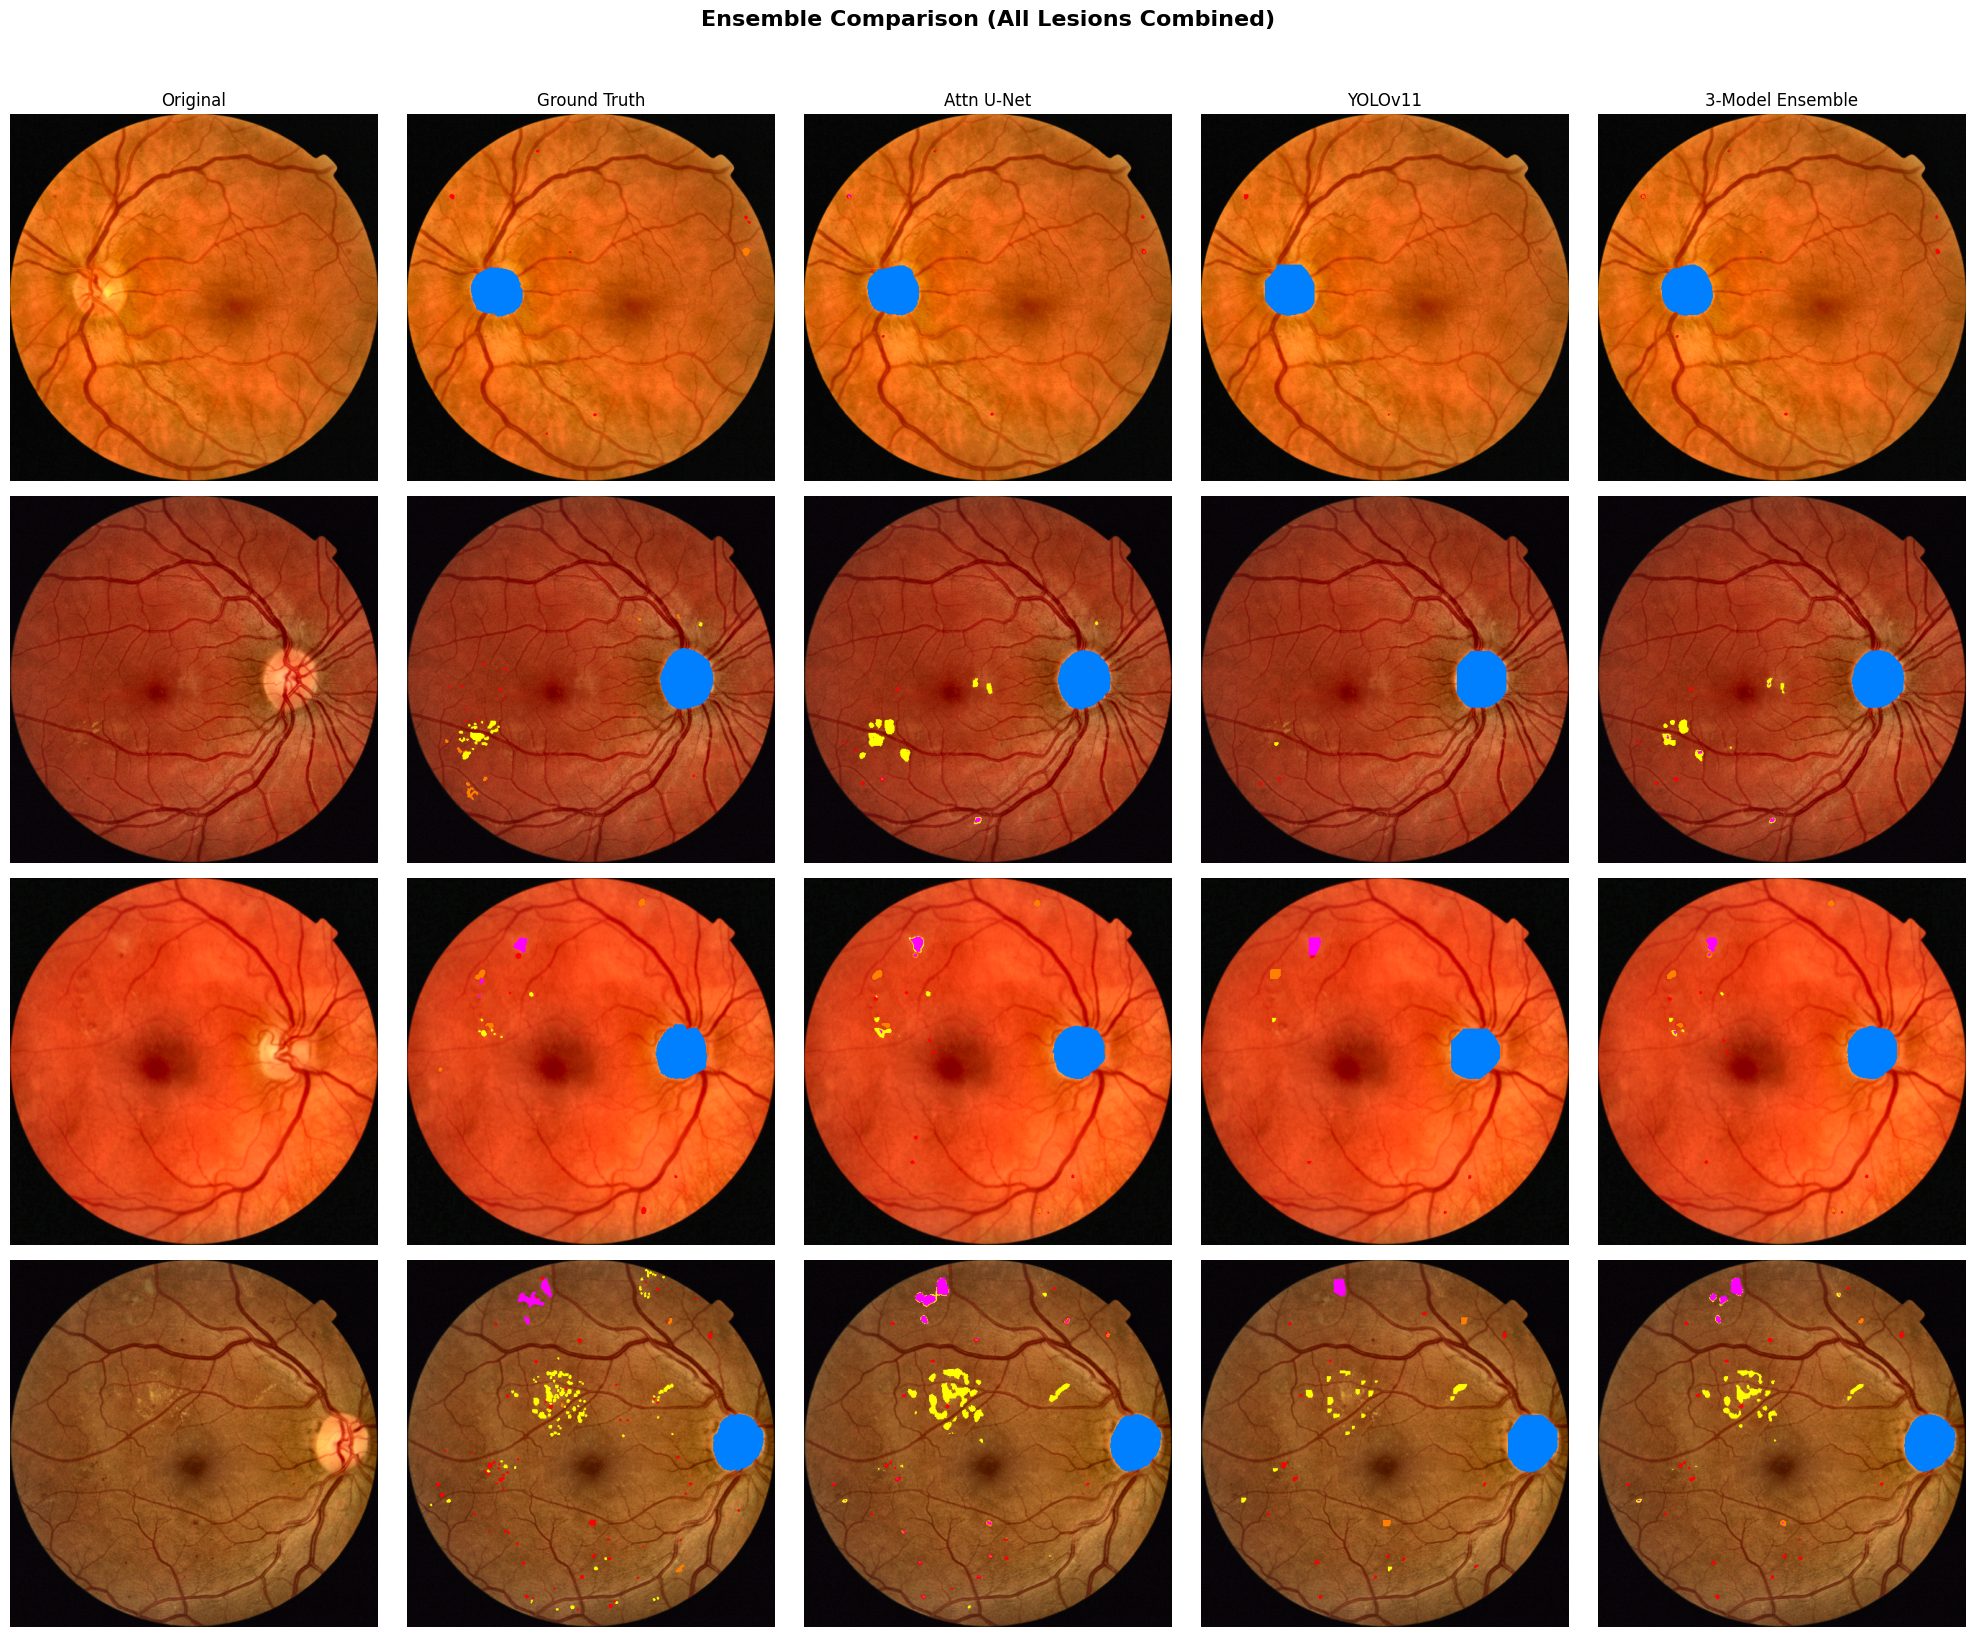

In [15]:
def denormalize(tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    tensor = tensor.cpu() * std + mean
    return torch.clamp(tensor, 0, 1).permute(1, 2, 0).numpy()

num_samples = 4
lesion_colors = {'MA': [1,0,0], 'HE': [1,0.5,0], 'EX': [1,1,0], 'OD': [0,0.5,1], 'CW': [1,0,1]}

fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4 * num_samples))
fig.suptitle('Ensemble Comparison (All Lesions Combined)', fontsize=16, fontweight='bold', y=1.02)

for i in range(num_samples):
    img_np = denormalize(test_dataset[i][0])

    # Titles
    if i == 0:
        axes[i,0].set_title('Original')
        axes[i,1].set_title('Ground Truth')
        axes[i,2].set_title('Attn U-Net')
        axes[i,3].set_title('YOLOv11')
        axes[i,4].set_title('3-Model Ensemble')

    # 0: Image
    axes[i,0].imshow(img_np)
    axes[i,0].axis('off')

    # Masks logic
    masks_to_draw = [
        all_targets[i],                       # GT
        (preds_attn[i] > 0.5),                # Attn UNet
        (preds_yolo[i] > 0.5),                # YOLO
        (ensemble_3_prob[i] > 0.5)            # Ensemble 3
    ]

    for col_idx, mask_set in enumerate(masks_to_draw):
        overlay = img_np.copy()
        for ch, lt in enumerate(LESION_TYPES):
            active_pixels = mask_set[ch] > 0.5
            overlay[active_pixels] = lesion_colors[lt]
        axes[i, col_idx + 1].imshow(overlay)
        axes[i, col_idx + 1].axis('off')

plt.tight_layout()
plt.show()


In [16]:
import json
import os

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

save_dir = 'lesion_results/Ensemble_Models'
os.makedirs(save_dir, exist_ok=True)

# 1. Save the Test Results JSON (Both Ensembles)
results_file = os.path.join(save_dir, 'Ensemble_results.json')

# We convert Numpy float formats to native Python floats to prevent JSON crashing
clean_ens2 = {k: float(v) for k, v in results_ens2.items()}
clean_ens3 = {k: float(v) for k, v in results_ens3.items()}

combined_results = {
    "2-Model_Ensemble_AttnUnet_YOLO": clean_ens2,
    "3-Model_Ensemble_AttnUnet_UnetPP_YOLO": clean_ens3
}

with open(results_file, 'w') as f:
    json.dump(combined_results, f, indent=4)
print(f"✅ Ensemble Metrics saved to {results_file}")

# 2. Save the Visualizations
vis_file = os.path.join(save_dir, 'Ensemble_Predictions_Comparison.png')
# Assuming 'fig' is still loaded in memory from the previous plotting cell!
fig.savefig(vis_file, dpi=200, bbox_inches='tight')
print(f"✅ Prediction Comparisons saved to {vis_file}")

# 3. Automatically Trigger Browser Downloads
if IN_COLAB:
    print("⏳ Triggering downloads in your browser...")
    files.download(results_file)
    files.download(vis_file)
else:
    print(f"Check the '{save_dir}' folder on your computer for the files!")


✅ Ensemble Metrics saved to lesion_results/Ensemble_Models/Ensemble_results.json
✅ Prediction Comparisons saved to lesion_results/Ensemble_Models/Ensemble_Predictions_Comparison.png
⏳ Triggering downloads in your browser...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

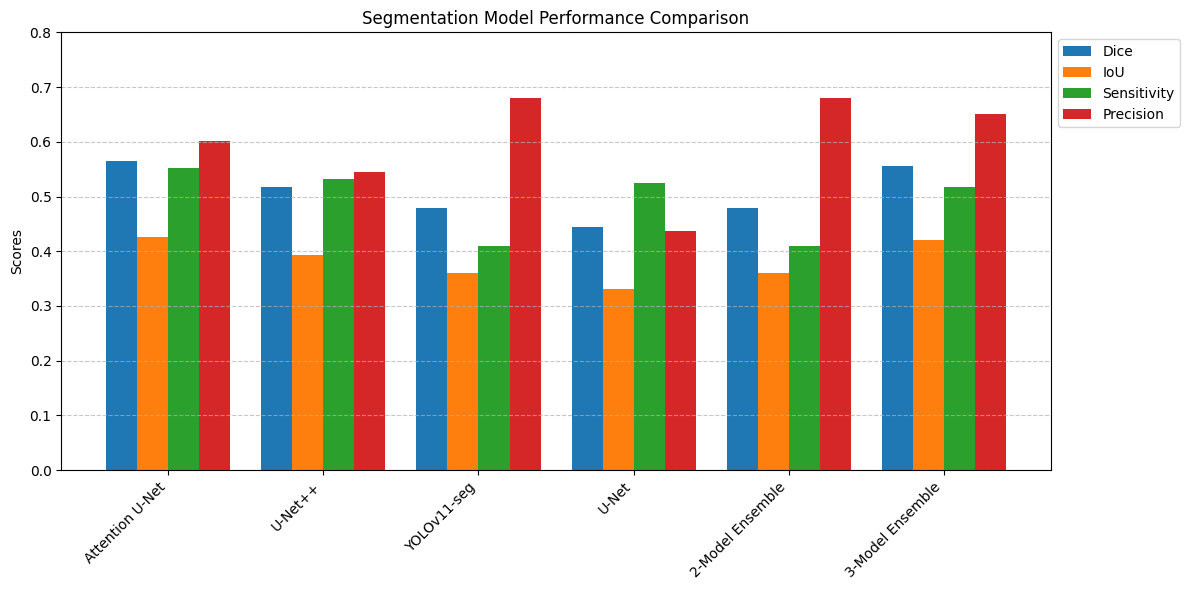

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_model_metrics():
    # 1. Define the combined data
    data = {
        "Model": [
            "Attention U-Net", "U-Net++", "YOLOv11-seg", "U-Net",
            "2-Model Ensemble", "3-Model Ensemble"
        ],
        "Dice": [0.5642, 0.5175, 0.4789, 0.4443, 0.4790, 0.5558],
        "IoU": [0.4267, 0.3931, 0.3603, 0.3307, 0.3603, 0.4204],
        "Sensitivity": [0.5521, 0.5315, 0.4090, 0.5245, 0.4090, 0.5171],
        "Precision": [0.6013, 0.5442, 0.6801, 0.4370, 0.6806, 0.6506]
    }

    df = pd.DataFrame(data)

    # 2. Set up the figure and axes
    metrics = ["Dice", "IoU", "Sensitivity", "Precision"]
    x = np.arange(len(df["Model"]))  # Label locations
    width = 0.2  # Width of the bars

    fig, ax = plt.subplots(figsize=(12, 6))

    # 3. Plot a set of bars for each metric
    for i, metric in enumerate(metrics):
        offset = (i - 1.5) * width
        bars = ax.bar(x + offset, df[metric], width, label=metric)

    # 4. Add labels, title, and formatting
    ax.set_ylabel('Scores')
    ax.set_title('Segmentation Model Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(df["Model"], rotation=45, ha="right")
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 0.8) # Adjust based on your max value to give breathing room

    # Add a subtle grid for readability
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Run the function
plot_model_metrics()